In [ ]:
#--------------------------------------------------------------------------------------
# Set up and Imports
#--------------------------------------------------------------------------------------
'''
Script to process the EHR data, extract treatment being considered, extract values from EHR, generate value profiles
at three alternate reading levels, and then generate treatment recommendations for each patient.

Includes code to reproduce Figure S4B for estimates of model uncertainty.

#Installation of Ollama needed initially:

#Download Ollama binary:
!curl -L https://ollama.com/download/ollama-linux-amd64 -o ~/local/bin/ollama

#Make executable:
!chmod +x ~/local/bin/ollama

#Ensure pip is available:
!conda install pip

#Install Python package:
!pip install ollama

#Run Ollama server:
!ollama serve

#Pull a model:
!ollama pull llama3

'''

In [ ]:

import torch
import pandas as pd
import numpy as np

import glob
import os
import time
import random
from tqdm import tqdm
import re

import ollama
import transformers

import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score
from itertools import combinations

from pytorch_lightning import seed_everything
from scipy import stats
from scipy.stats import sem, t, ttest_ind
from sentence_transformers import SentenceTransformer, util

#-------------------------------------------------------------------------------
# Environment / Device Setup
#-------------------------------------------------------------------------------

def is_notebook():
    return 'JPY_PARENT_PID' in os.environ

USE_CUDA = torch.cuda.is_available()
device = torch.device('cuda' if USE_CUDA else 'cpu')
current_directory = os.getcwd()

#-------------------------------------------------------------------------------
# Reproducibility
#-------------------------------------------------------------------------------

seed_everything(42, workers=True)

#-------------------------------------------------------------------------------
# Read in data
#-------------------------------------------------------------------------------
'''
Read in patient data: currently protected PHI

Preferred format:

patient_data.columns = ['patient_id','surgery_start','note_id','note_date','note_title','note_text']

patient_id: unique patient ID
surgery_start: start of surgergy time
note_id: unique note ID
note_date: time stamp of note
note_title: type of note e.d. progress, consult etc.
note_text: full text of note

# filter to patients with > 10 notes
# randomly sample 35 patients
# filter to only pre-surgical notes

'''


/blue/prismap-ai-core/vnolan/conda/envs/APARI_Models/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-04-21 11:54:55.333379: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[rank: 0] Seed set to 42


2857     50810
1523     17410
2203    142999
1345    239495
1302     15428
1242    183913
632     291510
2781     53416
94      255329
0       203640
549       1547
871     208150
2394    101130
1034    177331
3326    228383
16      314464
2452     55337
2666    109090
395     293530
874       1523
1609    195388
3196     86200
760      58330
1288    244029
2109    194676
438       7257
1243    191955
5680    178795
80      279733
2336    133776
133     300354
1443    194613
2948     48545
817     199101
4624     86382
Name: patient_id, dtype: int64
*** There are 35 patients
*** Earliest surgery: 2012-03-03 09:40:00
*** Latest surgery: 2023-01-30 11:58:00
*** GPU is available: True
*** Running off a Jupyter Notebook: True
*** Total number of notes: 4450


In [ ]:
#-------------------------------------------------------------------------------
# PROMPTS
#-------------------------------------------------------------------------------

prompt_extract_treatment = '''
Here is a set of clinical notes for a single patient admitted to hospital: {NOTES}. Use these notes to complete the following tasks:
Task 1) Summarize the clinical notes in as much detail as possible. Include information about the reason for admission, possible diagnoses, symptoms, comorbidities, family history, previous procedures or surgeries, lifestyle, and other useful information like background , living arrangements or family circumstances. 
Task 2) List all of the major clinical decisions, treatments, and procedures done or being considered for this patient, including hospital admission, all operations and major procedures, and discharge.
Task 3) Identify the primary decision made for the patient while in the hospital (i.e. the main procedure or surgery). Only pick one from the list of major clinical decisions in Task 2. 
'''

prompt_extract_values = '''
Here is a clinical note relating to a single patient admitted to hospital: {NOTES}. Your task is to extract any specific information about the values and preferences of this patient from this note. 
Look for things mentioning the importance of certain life aspects e.g. family, relationships, finances, travel, religion etc. and also the patient's wishes regarding end-of-life care, plus any mention of advanced care planning or advanced directives.
If there are specific values and preferences mentioned output them, but do not include any information which is not specifically mentioned in the notes and do not infer or generate new information.
If there is no information output a single answer '*No Information*'. Do not output any other text. 
'''

prompt_generate_values = '''
Here is a list of values and preferences relating to a single patient admitted to hospital: {NOTES}. Your task is to use this to write a summary as a paragraph of text. 
Include information about family, relationships, finances, travel, religion, lifestyle etc. and also the patient's wishes regarding end-of-life care, plus any mention of advanced care planning or advanced directives.
Use only information from the summary - do not generate new information or add anything new. Please make each answer at least 5-10 sentences long. You should give your answer written in three different styles:
    1) In the style of a 5th grade reading level. This is very easy to read and easily understood by an average 11-year-old student. This includes short sentences and words with fewer syllables.
    2) In the style of an 8th or 9th grade reading level. This is plain English and easily understood by 13- to 15-year-old students. Sentences will be longer with more words with multiple syllables.
    3) In the style of a college graduate. This is very difficult to read and best understood by university graduates. This will be longer sentences with multi-syllabic words.
Give your answers formatted so that each new style paragraph starts and ends with *** 
'''

prompt_treatment_recommendation = ''' 
Here is some information about a patient in hospital: {SCENARIO}. Here is also some information about their values and wishes: {VALUES}. Complete these two tasks:
1) Summarize the primary treatment decision in less than 5 words. 
2) Using the patient's values, output whether the patient should have been treated using the main treatment outlined - Yes or No, and give a reason? 
Do not suggest additional treatments. 
'''


In [ ]:
#-------------------------------------------------------------------------------
# Generate value profiles for each patient 
#-------------------------------------------------------------------------------
no_notes = []
all_data = []
all_values = []
raw_values = []

for patient_id in tqdm(patient_data['patient_id'].unique()):
    
    print(f'*---------------------------------------{patient_id}---------------------------------------------------*')
    
    ##--------------- STEP 1: PROCESSING TEXT -------------------------------------------------##
    def process_text(text):
        if not isinstance(text, str): return ""
        text = text.replace("[**DATE**]", "")
        text = text.replace("[**NAME**]", "")
        text = text.replace("[**AGE**]", "")
        text = text.replace("[**ID**]", "")
        text = text.replace("[**LOCATION_CITY**]", "")
        text = text.replace("[**LOCATION_INSTITUTE**]", "")
        text = text.replace("[**CONTACT_PHONE**]", "")
        text = re.sub(r'\s+', ' ', text)  
        return text
    
    def remove_duplicate_entries(text):   
        phrases = set(re.findall(r'\*(.*?)\*', text))   
        return '\n'.join(f'*{phrase}*' for phrase in phrases)
            
    patient_data_subset = patient_data[patient_data['patient_id'] == patient_id] 
    patient_data_subset = patient_data_subset.iloc[:, [2, 3, 4, 5]]
    no_notes.append(len(patient_data_subset)) 

    patient_data_subset['processed_text'] = patient_data_subset['note_text'].apply(process_text)
    patient_data_subset['note_date'] = pd.to_datetime(patient_data_subset['note_date'])
    patient_data_subset = patient_data_subset.sort_values(by='note_date', ascending=True)

    patient_data_subset['combined_text'] = patient_data_subset.apply(lambda row: 
            f"Note ID: {row['note_id']}, Datetime: {row['note_date']}, Type: {row['note_title']}, Text: {row['processed_text']}", axis=1)  
    
    ##--------------- Step 2: EXTRACTING TREATMENT DECISION FROM LAST 10 NOTES BEFORE SURGERY --------------------------##  

    patient_data_subset_last = patient_data_subset.tail(10)
    full_text = ' '.join(patient_data_subset_last['combined_text'])
    full_text = re.sub(r'Note ID:', '\nNote ID:', full_text) 
    subfolder = "ClinicalNotes"
    filename_full = f"Patient_{patient_id}.txt"
    file_path_full = os.path.join(subfolder, filename_full)

    with open(file_path_full, "w") as file: 
        file.write(full_text)            

    prompt = prompt_extract_treatment.format(NOTES=full_text)
    response = ollama.chat(model='llama3', options={'temperature': 0.2}, messages=[{'role': 'user', 'content': prompt}])
    all_data.append(" ".join([response['message']['content']]))
        
    ##--------------- Step 3: EXTRACTING VALUES FROM ALL NOTES   ---------------------------------------##

    row_data = []

    for _, row in tqdm(patient_data_subset.iterrows(), total=len(patient_data_subset), desc="Processing Notes"):
        full_text2 = row['combined_text']
        full_text2 = re.sub(r'Note ID:', '\nNote ID:', full_text2)            
        prompt2 = prompt_extract_values.format(NOTES=full_text2)
        response2 = ollama.chat(model='llama3', options={'temperature': 0.2}, messages=[{'role': 'user', 'content': prompt2}])   
        row_data.append(response2['message']['content']) 
        print(response2['message']['content'])

    final_text = re.sub(r'\*No Information\*', '', " ".join(row_data), flags=re.IGNORECASE)
    final_text = remove_duplicate_entries(final_text)
    raw_values.append(final_text)

    ##--------------- Step 4: GENERATING VALUE PROFILES   ---------------------------------------##

    retry = True

    while retry:
        try:        
            values = final_text
            prompt3 = prompt_generate_values.format(NOTES=values)
            response3 = ollama.chat(model='llama3', options={'temperature': 0.2}, messages=[{'role': 'user', 'content': prompt3}])
            sections = response3['message']['content'].split('***')
            sections = [section.strip() for section in sections if section.strip()]
            print(sections)
            if len(sections) >= 6:
                data = {
                    "5th Grade Level": sections[1],
                    "8th/9th Grade Level": sections[3],
                    "College Graduate Level": sections[5]}
                all_values.append(data)   
                retry = False
            else: 
                print(f"Retrying for patient ID {patient_id} - Expected 6 sections, got {len(sections)}: {sections}")
                
        except IndexError:
            print(f"IndexError encountered for patient ID: {patient_id}. Retrying this iteration.")            
        
print(max(no_notes), min(no_notes), np.mean(no_notes), np.std(no_notes))
df = pd.DataFrame(all_data)
df_val = pd.DataFrame(all_values)
df_raw_vals = pd.DataFrame(raw_values)

df.to_csv('GeneratedValueProfiles_ClinicalNotes1.csv', index=False). # save out summaries of EHR data
df_val.to_csv('GeneratedValueProfiles_ClinicalNotes2.csv', index=False). # save out patient value profiles at each reading level
df_raw_vals.to_csv('GeneratedValueProfiles_ClinicalNotes3.csv', index=False) # save out raw extracted patient values for reference


#--------------------------------------------------------------------------------------
# Final prompting for a treatment decision for each patient 
#--------------------------------------------------------------------------------------

df_sum = pd.read_csv('GeneratedValueProfiles_ClinicalNotes1.csv', encoding='ISO-8859-1')
df_val = pd.read_csv('GeneratedValueProfiles_ClinicalNotes2.csv', encoding='ISO-8859-1')

for patient in range(len(df_sum)):
    
    print(f'*--------------------------------- Patient {patient} --------------------------------*')
    sum_text = df_sum.iloc[patient, 0] 
    value_1 = df_val.iloc[patient, 0]
    value_2 = df_val.iloc[patient, 1]
    value_3 = df_val.iloc[patient, 2]

    prompt = prompt_treatment_recommendation.format(SCENARIO=sum_text, VALUES=value_1)
    response1 = ollama.chat(model='llama3', options={'temperature': 0.2}, messages=[{'role': 'system', 'content': prompt}])
    print('*** READING LEVEL 5:', response1['message']['content'])
    print()
    
    prompt = prompt_treatment_recommendation.format(SCENARIO=sum_text, VALUES=value_2)
    response2 = ollama.chat(model='llama3', options={'temperature': 0.2}, messages=[{'role': 'system', 'content': prompt}])
    print('*** READING LEVEL 8/9', response2['message']['content'])
    print()
    
    prompt = prompt_treatment_recommendation.format(SCENARIO=sum_text, VALUES=value_3)
    response3 = ollama.chat(model='llama3', options={'temperature': 0.2}, messages=[{'role': 'system', 'content': prompt}])
    print('*** READING LEVEL COLLEGE GRAD:', response3['message']['content'])
    print()
    

In [ ]:
#--------------------------------------------------------------------------------------
# Generating estimates of model uncertainty using cosine similarity
#--------------------------------------------------------------------------------------

model = SentenceTransformer('all-MiniLM-L6-v2')
df_sum = pd.read_csv('GeneratedValueProfiles_ClinicalNotes1.csv', encoding='ISO-8859-1')
df_val = pd.read_csv('GeneratedValueProfiles_ClinicalNotes2.csv', encoding='ISO-8859-1')

no_runs = 10
reading_level_sim1 = []
reading_level_sim2 = []
reading_level_sim3 = []

for patient in range(len(df_sum)):
    
    print(f'*--------------------------------- Patient {patient} --------------------------------*')
    sum_text = df_sum.iloc[patient, 0] 
    value_1 = df_val.iloc[patient, 0]
    value_2 = df_val.iloc[patient, 1]
    value_3 = df_val.iloc[patient, 2]
    
    reading1 = []
    reading2 = []
    reading3 = []
    
    for run in tqdm(range(no_runs)):       
        
        prompt = prompt_treatment_recommendation.format(SCENARIO=sum_text, VALUES=value_1)
        response1 = ollama.chat(model='llama3', options={'temperature': 0.2}, messages=[{'role': 'system', 'content': prompt}])
        #match = re.search(r"2\.\s*(.*)", response1['message']['content'], re.DOTALL)
        #answer_2 = match.group(1).strip() if match else None
        reading1.append(response1['message']['content'])

        prompt = prompt_treatment_recommendation.format(SCENARIO=sum_text, VALUES=value_2)
        response2 = ollama.chat(model='llama3', options={'temperature': 0.2}, messages=[{'role': 'system', 'content': prompt}])
        #match = re.search(r"2\.\s*(.*)", response2['message']['content'], re.DOTALL)
        #answer_2 = match.group(1).strip() if match else None
        reading2.append(response2['message']['content'])
    
        prompt = prompt_treatment_recommendation.format(SCENARIO=sum_text, VALUES=value_3)
        response3 = ollama.chat(model='llama3', options={'temperature': 0.2}, messages=[{'role': 'system', 'content': prompt}])
        #match = re.search(r"2\.\s*(.*)", response3['message']['content'], re.DOTALL)
        #answer_2 = match.group(1).strip() if match else None
        reading3.append(response3['message']['content'])

    embeddings1 = model.encode(reading1, convert_to_tensor=True)
    embeddings2 = model.encode(reading2, convert_to_tensor=True)
    embeddings3 = model.encode(reading3, convert_to_tensor=True)

    similarity_matrix1 = util.cos_sim(embeddings1, embeddings1).cpu().numpy()
    similarity_df1 = pd.DataFrame(similarity_matrix1, columns=[f"String {i+1}" for i in range(len(reading1))], index=[f"String {i+1}" for i in range(len(reading1))])
    similarity_matrix2 = util.cos_sim(embeddings2, embeddings2).cpu().numpy()
    similarity_df2 = pd.DataFrame(similarity_matrix2, columns=[f"String {i+1}" for i in range(len(reading2))], index=[f"String {i+1}" for i in range(len(reading2))])
    similarity_matrix3 = util.cos_sim(embeddings3, embeddings3).cpu().numpy()    
    similarity_df3 = pd.DataFrame(similarity_matrix3, columns=[f"String {i+1}" for i in range(len(reading3))], index=[f"String {i+1}" for i in range(len(reading3))])
    
    main_diagonal_mask = ~np.eye(similarity_matrix1.shape[0], dtype=bool)
    off_diagonal_elements1 = similarity_matrix1[main_diagonal_mask]
    reading_level_sim1.append(off_diagonal_elements1)
    
    main_diagonal_mask = ~np.eye(similarity_matrix2.shape[0], dtype=bool)
    off_diagonal_elements2 = similarity_matrix2[main_diagonal_mask]
    reading_level_sim2.append(off_diagonal_elements2)

    main_diagonal_mask = ~np.eye(similarity_matrix3.shape[0], dtype=bool)
    off_diagonal_elements3 = similarity_matrix3[main_diagonal_mask]
    reading_level_sim3.append(off_diagonal_elements3)

#--------------------------------------------------------------------------------------
# Visual and statistical analysis of the simulated reading level results: Figure S4B
#--------------------------------------------------------------------------------------
    
## ANOVA TEST OF MEANS BETWEEN READING LEVELS
data = [reading_level_sim1, reading_level_sim2, reading_level_sim3]
f_statistic, p_value = f_oneway(np.array(reading_level_sim1).flatten(), np.array(reading_level_sim2).flatten(), np.array(reading_level_sim3).flatten())
print(f"F-statistic: {f_statistic}")
print(f"P-value: {p_value}")
if p_value < 0.05: print("There is a significant difference between the means of the reading levels.")
else: print("There is no significant difference between the means of the reading levels.")
means = [np.mean(d) for d in data]
std_devs = [np.std(d, ddof=1) for d in data] 
sample_sizes = [len(d) for d in data]
confidence_intervals = []
alpha = 0.05 
for i in range(len(data)):
    t_value = t.ppf(1 - alpha / 2, df=sample_sizes[i] - 1)  # t critical value
    margin_of_error = t_value * (std_devs[i] / np.sqrt(sample_sizes[i]))
    confidence_intervals.append(margin_of_error)
    
# Create a DataFrame for OLS
reading_level_sim1 = np.array(reading_level_sim1).flatten()
reading_level_sim2 = np.array(reading_level_sim2).flatten()
reading_level_sim3 = np.array(reading_level_sim3).flatten()
data = {'score': np.concatenate([reading_level_sim1, reading_level_sim2, reading_level_sim3]),
        'group': (['Level 1'] * len(reading_level_sim1)) +
             (['Level 2'] * len(reading_level_sim2)) +
             (['Level 3'] * len(reading_level_sim3))}
             
df = pd.DataFrame(data)
model = smf.ols('score ~ group', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)
    

Cohen's d: 0.025


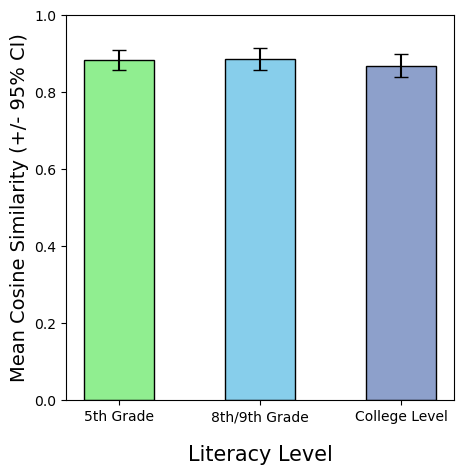

In [ ]:

d1, d2, d3 = reading_level_sim1, reading_level_sim2, reading_level_sim3
mean_diff = abs(np.mean(d1) - np.mean(d2))
pooled_std = np.sqrt((np.std(d1, ddof=1) ** 2 + np.std(d2, ddof=1) ** 2) / 2)
cohen_d = mean_diff / pooled_std
print(f"Cohen's d: {cohen_d:.3f}")    

## PLOT OF SAMPLE CONSISTENCY OVER READING LEVELS: FIGURE 4B
fig, ax = plt.subplots(figsize=(5, 5))
bars = ax.bar([0, 1, 2], means, yerr=confidence_intervals, capsize=5, color=['lightgreen', 'skyblue', '#8da0cb'], edgecolor='black', width =0.5)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['5th Grade', '8th/9th Grade', 'College Level'])
ax.set_ylabel('Mean Cosine Similarity (+/- 95% CI)', fontsize=14)
ax.set_xlabel('Literacy Level', size = 15, labelpad=15)
ax.set_ylim(0.0, 1.0)
plt.show()
print(means, confidence_intervals)